In [4]:
#/notebooks/data_exploration.ipynb

# Cell 1: fetch data and create df
import sys
import os
from dotenv import load_dotenv
import pandas as pd
from supabase import create_client, Client

# Change directory to the project root
os.chdir("/Users/mattb/Desktop/Projects/score-genius")

# Append the backend directory to sys.path so that modules can be imported
sys.path.append(os.path.join(os.getcwd(), "backend"))

# Optionally, print the sys.path to confirm
print("sys.path:", sys.path)


# Assuming your working directory is the project root (which contains both /backend and /notebooks)
sys.path.append(os.path.join(os.getcwd(), "backend"))
os.chdir("/Users/mattb/Desktop/Projects/score-genius")


load_dotenv(dotenv_path='../.env')

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_ANON_KEY = os.getenv("SUPABASE_ANON_KEY")

supabase: Client = create_client(SUPABASE_URL, SUPABASE_ANON_KEY)
response = supabase.table("nba_historical_game_stats").select("*").execute()

# Depending on your supabase library’s response structure:
data = response.data  # or response.get("data")

df = pd.DataFrame(data)
print("DataFrame created. Shape:", df.shape)
print(os.getcwd())


sys.path: ['/Users/mattb/Desktop/Projects/score-genius/backend', '/usr/local/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/usr/local/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/usr/local/Cellar/python@3.11/3.11.11/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/mattb/Desktop/Projects/score-genius/backend/venv_pytorch/lib/python3.11/site-packages', '/Users/mattb/Desktop/Projects/score-genius/backend', '/Users/mattb/Desktop/Projects/score-genius/backend', '/Users/mattb/Desktop/Projects/score-genius/backend']
DataFrame created. Shape: (1000, 38)
/Users/mattb/Desktop/Projects/score-genius


In [5]:
# Cell 2: operate on df
print(df.dtypes)

# Maybe filter for Knicks
knicks_df = df[df['home_team'].str.contains("Knicks", case=False, na=False)]
print(knicks_df.head())


id                 int64
game_id            int64
home_team         object
away_team         object
home_score         int64
away_score         int64
home_q1            int64
home_q2            int64
home_q3            int64
home_q4            int64
home_ot            int64
away_q1            int64
away_q2            int64
away_q3            int64
away_q4            int64
away_ot            int64
game_date         object
updated_at        object
home_assists       int64
home_steals        int64
home_blocks        int64
home_turnovers     int64
home_fouls         int64
away_assists       int64
away_steals        int64
away_blocks        int64
away_turnovers     int64
away_fouls         int64
home_off_reb       int64
home_def_reb       int64
home_total_reb     int64
away_off_reb       int64
away_def_reb       int64
away_total_reb     int64
home_3pm           int64
home_3pa           int64
away_3pm           int64
away_3pa           int64
dtype: object
      id  game_id        home_team  

In [6]:
print(df.columns)

Index(['id', 'game_id', 'home_team', 'away_team', 'home_score', 'away_score',
       'home_q1', 'home_q2', 'home_q3', 'home_q4', 'home_ot', 'away_q1',
       'away_q2', 'away_q3', 'away_q4', 'away_ot', 'game_date', 'updated_at',
       'home_assists', 'home_steals', 'home_blocks', 'home_turnovers',
       'home_fouls', 'away_assists', 'away_steals', 'away_blocks',
       'away_turnovers', 'away_fouls', 'home_off_reb', 'home_def_reb',
       'home_total_reb', 'away_off_reb', 'away_def_reb', 'away_total_reb',
       'home_3pm', 'home_3pa', 'away_3pm', 'away_3pa'],
      dtype='object')


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df_numeric = df.select_dtypes(include=[np.number])
print(df_numeric.head())


     id  game_id  home_score  away_score  home_q1  home_q2  home_q3  home_q4  \
0  7096   373226         104         102       29       18       28       29   
1     6   104117         122         119       32       31       24       35   
2     7   104118         100          83       22       20       29       29   
3     8   104119          80         113       28       19       26        7   
4     9   104120          95         106       22       18       30       25   

   home_ot  away_q1  ...  home_off_reb  home_def_reb  home_total_reb  \
0        0       22  ...             5            35              40   
1        0       33  ...            10            35              45   
2        0       18  ...             9            44              53   
3        0       32  ...             7            33              40   
4        0       21  ...            10            36              46   

   away_off_reb  away_def_reb  away_total_reb  home_3pm  home_3pa  away_3pm  \
0      

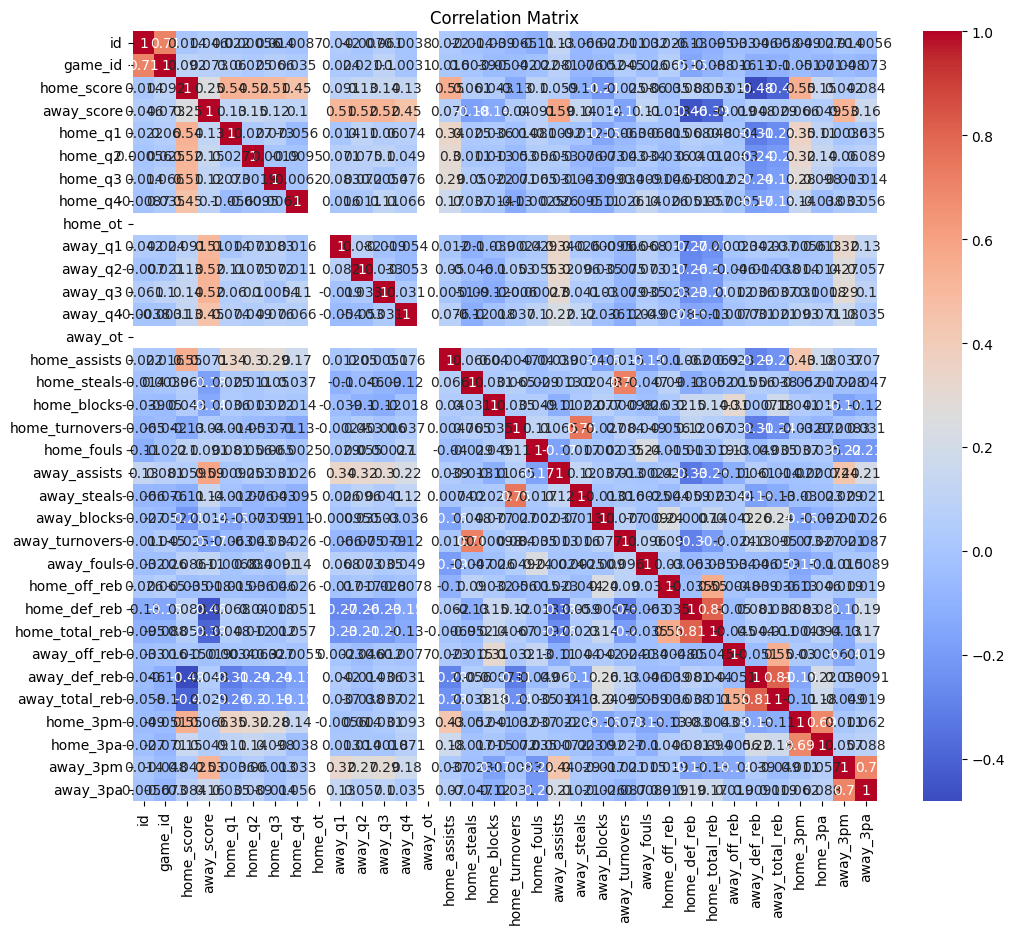

In [9]:
corr = df_numeric.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
